# Simple Linear Regression
## Predicting AQI from Month

**What is Simple Linear Regression?**
- We have ONE input: Month (X)
- We have ONE output: AQI (y)
- We find a line: **y = mx + b**

**Simple Steps:**
1. Load data
2. Prepare X and y
3. Split train/test
4. Train model
5. Make predictions
6. Check accuracy

## Step 1: Load and Check Data

In [1]:
# Step 1: Import libraries (Like CAProject.py)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("✓ All libraries imported (similar to CAProject.py)")

✓ All libraries imported (similar to CAProject.py)


## Step 1: Load Data

In [2]:
# Load data
df = pd.read_csv('../Data/processed/clean_data.csv')

print(f"Total records: {len(df)}")
print(f"\nFirst 3 rows:")
print(df[['month', 'aqi_value']].head(3))

Total records: 425279

First 3 rows:
   month  aqi_value
0      6         49
1      6         46
2      6         26


In [3]:
# Clean data - remove missing values
df_clean = df[['month', 'aqi_value']].dropna()

print(f"Clean records: {len(df_clean)}")
print(f"Removed: {len(df) - len(df_clean)}")

Clean records: 425279
Removed: 0


Skewness: 1.4276
Method used: IQR
Rows before: 425279
Rows after : 403879
Outliers removed: 21400


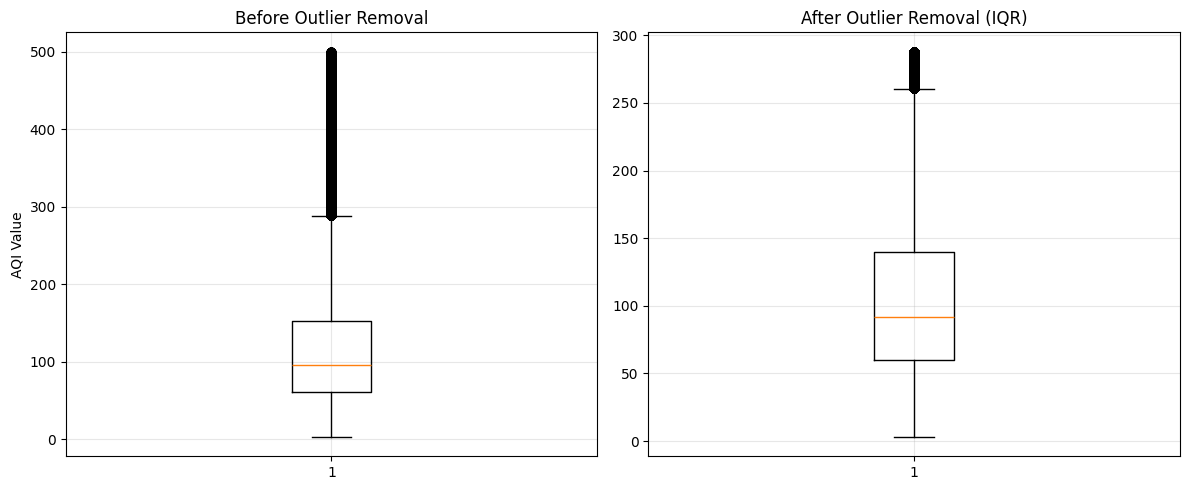

In [4]:
# Step 1.5: Simple outlier handling (aqi_value)
# Rule: skewed data -> IQR, otherwise -> Z-score

target_col = 'aqi_value'
skew_val = df_clean[target_col].skew()

df_before = df_clean.copy()

if abs(skew_val) > 0.5:
    q1 = df_clean[target_col].quantile(0.25)
    q3 = df_clean[target_col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    df_clean = df_clean[(df_clean[target_col] >= lower) & (df_clean[target_col] <= upper)].copy()
    method_used = 'IQR'
else:
    z_scores = np.abs(stats.zscore(df_clean[target_col], nan_policy='omit'))
    df_clean = df_clean[z_scores < 3].copy()
    method_used = 'Z-score'

print(f"Skewness: {skew_val:.4f}")
print(f"Method used: {method_used}")
print(f"Rows before: {len(df_before)}")
print(f"Rows after : {len(df_clean)}")
print(f"Outliers removed: {len(df_before) - len(df_clean)}")

# Boxplot comparison: before vs after
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].boxplot(df_before[target_col], vert=True)
ax[0].set_title('Before Outlier Removal')
ax[0].set_ylabel('AQI Value')
ax[0].grid(alpha=0.3)

ax[1].boxplot(df_clean[target_col], vert=True)
ax[1].set_title(f"After Outlier Removal ({method_used})")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Step 2: Prepare Data

In [5]:
# Prepare X (input) and y (output)
X = df_clean[['month']].values
y = df_clean['aqi_value'].values

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data: {len(X_train)}")
print(f"Testing data: {len(X_test)}")

Training data: 340223
Testing data: 85056


## Step 3: Train Model

In [6]:
# Create and train model
model = LinearRegression()
model.fit(X_train, y_train)

# Get model parameters
slope = model.coef_[0]
intercept = model.intercept_

print("Model trained!")
print(f"\nFormula: AQI = {intercept:.2f} + {slope:.4f} × Month")
print(f"\nSlope: {slope:.4f}")
print(f"Intercept: {intercept:.2f}")

Model trained!

Formula: AQI = 117.47 + 0.1714 × Month

Slope: 0.1714
Intercept: 117.47


## Step 4: Make Predictions

In [7]:
# Predict on test set
y_pred = model.predict(X_test)

# Show sample predictions
print("Sample Predictions:\n")
for i in range(5):
    print(f"Month {X_test[i][0]:.0f}: Actual={y_test[i]:.1f}, Predicted={y_pred[i]:.1f}")

Sample Predictions:

Month 1: Actual=72.0, Predicted=117.6
Month 8: Actual=47.0, Predicted=118.8
Month 10: Actual=56.0, Predicted=119.2
Month 10: Actual=72.0, Predicted=119.2
Month 4: Actual=259.0, Predicted=118.2


## Step 5: Evaluate Model

In [8]:
# Calculate accuracy metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Performance:\n")
print(f"R² Score: {r2:.4f}")
print(f"  → Explains {r2*100:.1f}% of AQI")
print(f"\nMSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"  → Average error: ±{rmse:.2f} AQI")

Model Performance:

R² Score: -0.0001
  → Explains -0.0% of AQI

MSE: 6374.42
RMSE: 79.84
  → Average error: ±79.84 AQI


## Step 6: Visualize Results

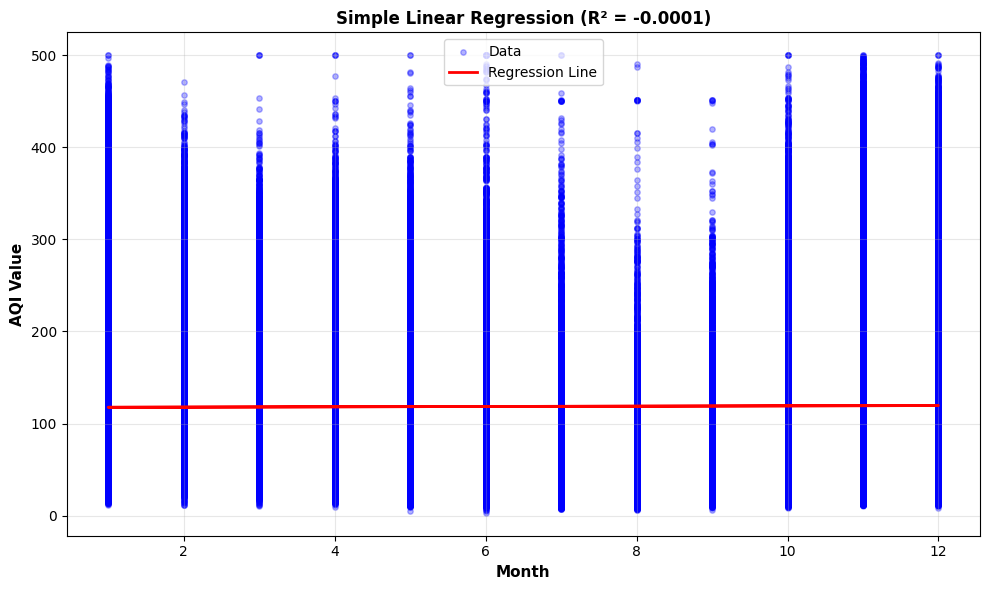

✓ Plot displayed


In [9]:
# Plot regression line
plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.3, s=15, color='blue', label='Data')
plt.plot(X, model.predict(X), color='red', linewidth=2, label='Regression Line')
plt.xlabel('Month', fontsize=11, fontweight='bold')
plt.ylabel('AQI Value', fontsize=11, fontweight='bold')
plt.title(f'Simple Linear Regression (R² = {r2:.4f})', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✓ Plot displayed")

## Step 7: Summary

In [10]:
# Summary
print("="*50)
print("SIMPLE LINEAR REGRESSION SUMMARY")
print("="*50)

print(f"\n✓ Model trained with {len(X_train)} records")
print(f"\n✓ Formula: AQI = {intercept:.2f} + {slope:.4f} × Month")
print(f"\n✓ Accuracy (R²): {r2:.4f}")
print(f"✓ Error (RMSE): {rmse:.2f} AQI points")
print(f"\n✓ Tested on {len(X_test)} records")

print("\n" + "="*50)
print("Ready for evaluation!")
print("="*50)

SIMPLE LINEAR REGRESSION SUMMARY

✓ Model trained with 340223 records

✓ Formula: AQI = 117.47 + 0.1714 × Month

✓ Accuracy (R²): -0.0001
✓ Error (RMSE): 79.84 AQI points

✓ Tested on 85056 records

Ready for evaluation!
